In [1]:
import bldw
import numpy as np
import blimpy as bl
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import setigen as stg
from astropy import units as u
import h5py
%matplotlib inline

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

numexpr.utils   INFO     Note: NumExpr detected 40 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
numexpr.utils   INFO     NumExpr defaulting to 8 threads.


In [8]:
rcvr = 'Rcvr2_3'
freq = 2226.470628 # MHz
mjd = 57628
ws = 8000e-6 # window size in MHz

In [3]:
df = pd.read_csv('/datax/scratch/benjb/bl_nearby_stars/BL_cadences_unique_nearby_star_sample_only.csv')
dff = df.iloc[np.where(df['Receiver'].values==rcvr)]
potential_h5s = dff['.h5 path 1'].values
useful_h5s = []
for ii, h5 in enumerate(potential_h5s):
    if ii%10 == 0:
        print(f'{ii} out of {len(potential_h5s)}')
    if 'spliced' in h5:
        continue
    with h5py.File(h5, 'r') as f:
        obj = f['data']
        attr = obj.attrs
        fch1 = attr['fch1']
        fch2 = fch1+attr['foff']*attr['nchans']
        if (freq > np.min([fch1, fch2])) & (freq < np.max([fch1, fch2])):
            useful_h5s.append(h5)

useful_h5s = np.array(useful_h5s)
print(len(potential_h5s))
print(len(useful_h5s))

0 out of 2103
10 out of 2103
20 out of 2103
30 out of 2103
40 out of 2103
50 out of 2103
60 out of 2103
70 out of 2103
80 out of 2103
90 out of 2103
100 out of 2103
110 out of 2103
120 out of 2103
130 out of 2103
140 out of 2103
150 out of 2103
160 out of 2103
170 out of 2103
180 out of 2103
190 out of 2103
200 out of 2103
210 out of 2103
220 out of 2103
230 out of 2103
240 out of 2103
250 out of 2103
260 out of 2103
270 out of 2103
280 out of 2103
290 out of 2103
300 out of 2103
310 out of 2103
320 out of 2103
330 out of 2103
340 out of 2103
350 out of 2103
360 out of 2103
370 out of 2103
380 out of 2103
390 out of 2103
400 out of 2103
410 out of 2103
420 out of 2103
430 out of 2103
440 out of 2103
450 out of 2103
460 out of 2103
470 out of 2103
480 out of 2103
490 out of 2103
500 out of 2103
510 out of 2103
520 out of 2103
530 out of 2103
540 out of 2103
550 out of 2103
560 out of 2103
570 out of 2103
580 out of 2103
590 out of 2103
600 out of 2103
610 out of 2103
620 out of 2103
630

In [4]:
h5_mjds = np.array([int(h5.split('guppi_')[1][:5]) for h5 in useful_h5s])

print(h5_mjds)
mjd_filtered_h5s = useful_h5s[np.where(np.abs(h5_mjds-mjd)<150)]
print(len(mjd_filtered_h5s))

[58732 58019 58019 58731 58731 58731 57798 57798 58732 58223 57798 58731
 57798 58731 58731 59546 57831 58643 58731 58018 59546 58018 58018 57831
 58643 57831 58643 57831 57831 58731 58731 58643 58732 59546 58731 58643
 58731 58643 58703 58703 59546 58018 58703 58522 58522 58522 59546 58599
 58599 58741 58522 58522 58522 58522 58522 58522 58018 58522 58522 58522
 58599 58522 58522 58522 58522 58522 58522 58522 58522 58643 58599 58599
 58643 58599 58599 58643 58643 58643 57872 58731 57872 58599 58599 57876
 58885 57876 58643 57877 57877 58643 59546 58643 58643 59546 59546 58643
 58754 60141 58643 58643 58643 58731 58731 58594 59567 58007 58731 58008
 58008 58594 58643 58731 58008 58008 58731 58014 58014 58731 57880 57880
 57880 57880 57880 57880 59567]
0


In [5]:
if len(useful_h5s) > 50:
    choice_h5s = np.random.choice(useful_h5s, 50, replace=False)
else:
    choice_h5s = useful_h5s

In [6]:
print(len(choice_h5s))

50


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


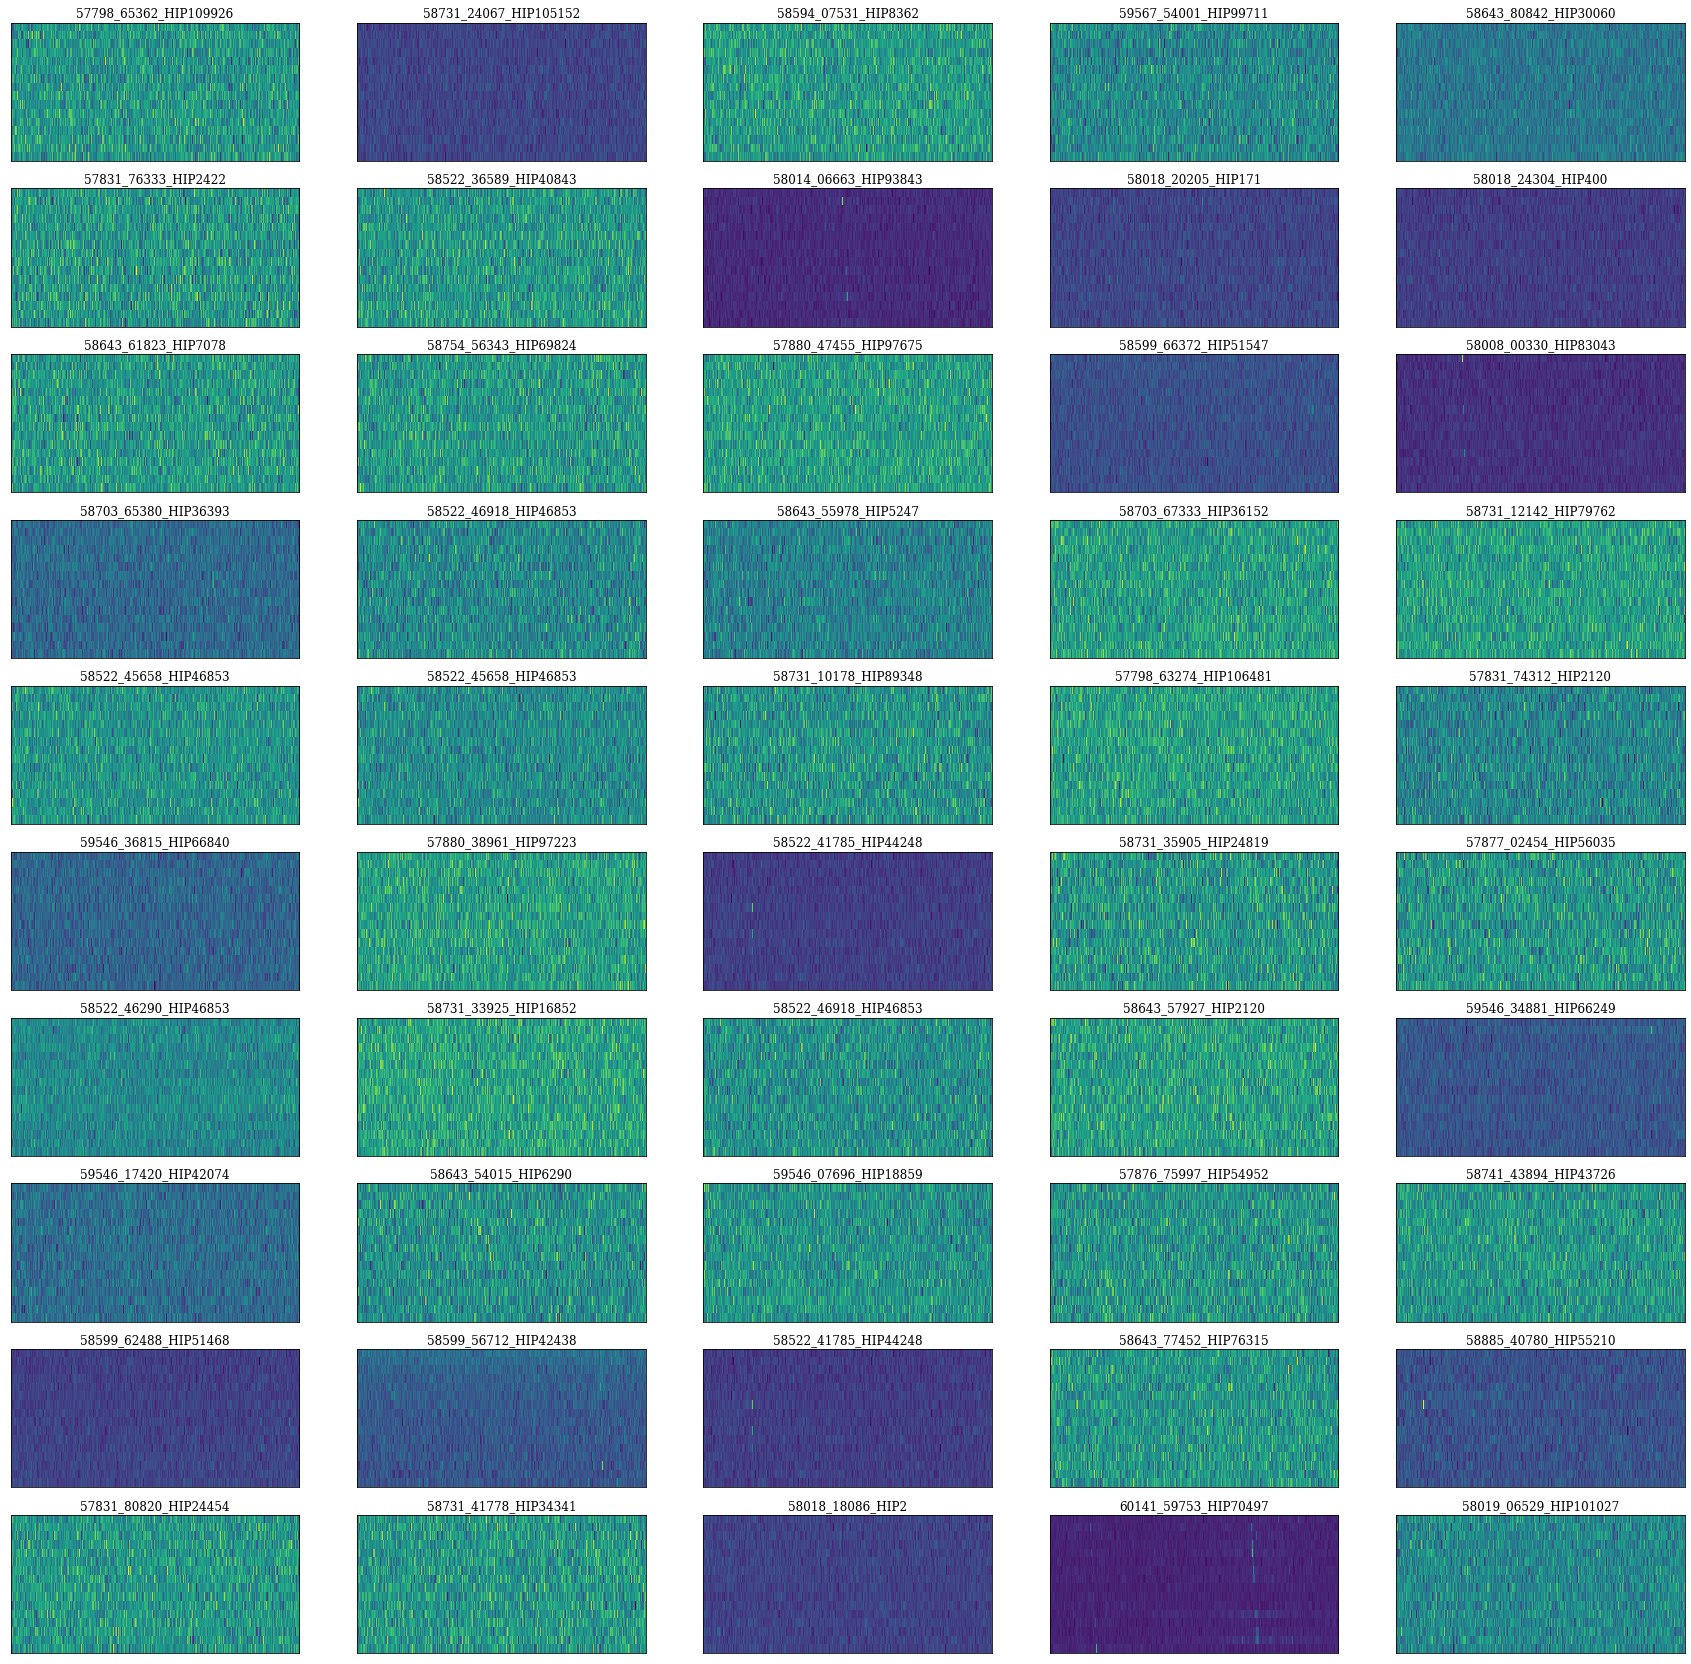

In [9]:
fig, ax = plt.subplots(10, 5, figsize=(30,30))

for k, h5 in enumerate(choice_h5s):
    i = k//5
    j = k%5
    print(k)

    fb = bl.Waterfall(h5, f_start=freq-ws/2, f_stop=freq+ws/2)
    data = np.squeeze(fb.data)
    ax[i,j].imshow(np.log10(data), aspect='auto', interpolation='none')
    ax[i,j].set_xticks([])
    ax[i,j].set_yticks([])
    ax[i,j].set_title(h5.split('guppi_')[1][:-21])

plt.savefig(f'check_{freq}.pdf', bbox_inches='tight')
plt.show()